In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('../data/tanzania.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


## Tanzania: Data Loading and Preparation

This dataset contains daily climate observations from January 2015 to March 2026 for Tanzania

**Key steps performed:**
1. Loaded CSV using `pd.read_csv('../data/tanzania.csv')`
2. Added 'Country' column with value 'Tanzania'
3. Converted YEAR and DOY to proper datetime format
4. Extracted Month and Year columns for seasonal analysis

**Dataset shape:** 4,108 rows × 15 columns

In [4]:

print(df.shape)
print(df.shape[0],df.shape[1])
print(df.columns.tolist()) 
df.info()

(4108, 12)
4108 12
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB


## Data Quality Assessment

### Missing Values
- **-999 sentinel values replaced with NaN:** No values replaced

### Duplicate Rows
- **Duplicate rows found:** None

### Data Types
All columns have appropriate data types (integers for YEAR, floats for weather variables).

In [5]:
df['Country'] = 'Tanzania'
df['Date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'],format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [6]:
print(df.duplicated().sum())

0


In [7]:
print(f"Number of -999 values before replacement: {(df == -999).sum().sum()}")

Number of -999 values before replacement: 0


In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046,3.248907


In [9]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df_outliers = df[weather_cols].copy()
z_scores = np.abs(stats.zscore(df_outliers))
outliers = (z_scores > 3)

# This gives you counts PER COLUMN
outlier_counts = outliers.sum()
print("Outlier counts per column:")
print(outlier_counts)

# This gives you total rows with at least one outlier
outlier_rows = outliers.any(axis=1).sum()
print(f"\nTotal rows with at least one outlier: {outlier_rows}")

Outlier counts per column:
102

Total rows with at least one outlier: 97


In [10]:
import os
makedir = os.makedirs('data',exist_ok=True)
df.to_csv('../data/tanzania_clean.csv')

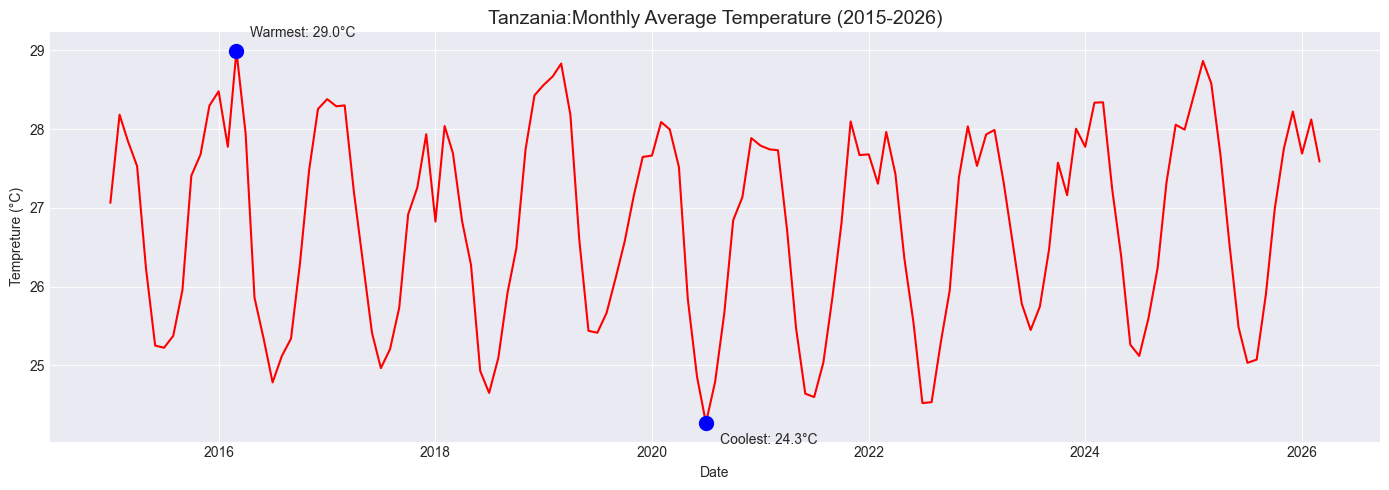

In [14]:
#plot for monthly tanzania temprature data
monthly_temp = df.groupby(['Year','Month'])['T2M'].mean().reset_index()  #this creates a table called monthly_temp that holds average of each month of each year
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str)+'-'+monthly_temp['Month'].astype(str))

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_temp['Date'],monthly_temp['T2M'],color='red',linewidth=1.5)

warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]
# print(warmest)
# print(coolest)
ax.scatter(warmest['Date'],warmest['T2M'],color='blue',s=100,zorder=5)
ax.scatter(coolest['Date'],coolest['T2M'],color='blue',s=100,zorder=5)

ax.set_title('Tanzania:Monthly Average Temperature (2015-2026)',fontsize=14)
ax.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', 
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points', fontsize=10)

ax.annotate(f'Coolest: {coolest["T2M"]:.1f}°C',
            xy=(coolest['Date'], coolest['T2M']), #xy cordiante where the point will be
            xytext=(10, -15), textcoords='offset points', fontsize=10)

ax.set_xlabel('Date')
ax.set_ylabel('Tempreture (°C)')
ax.grid(True,alpha =0.9)

plt.tight_layout()
plt.show() 

## Temperature Trend Analysis

**Key Findings:**
- **Warmest month:** March,2016 at 28.9°C
- **Coolest month:** July,2020 at 24.3°C


[     Year  Month  PRECTOTCORR       Date
39   2018      4       482.27 2018-04-01
27   2017      4       451.12 2017-04-01
108  2024      1       428.57 2024-01-01]


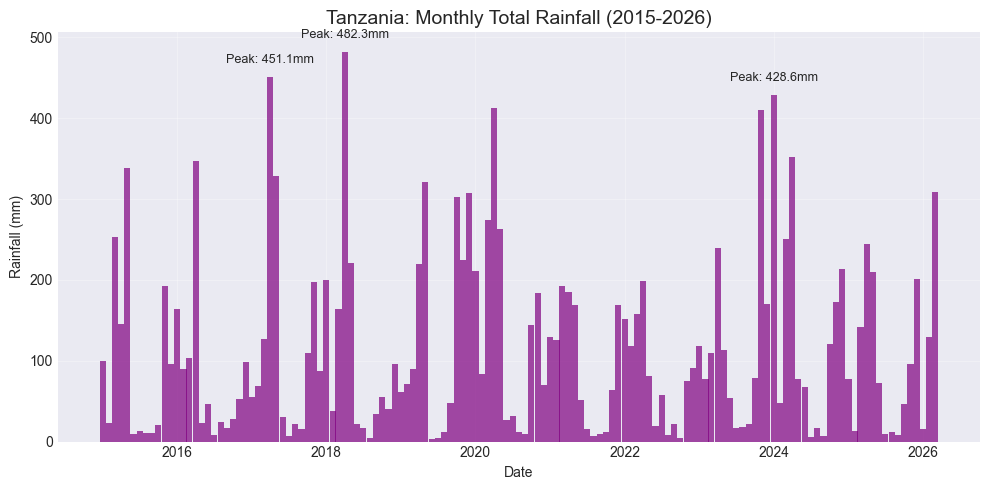

In [16]:
#plot for monthly tanzania rain graph
monthly_rain = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
monthly_rain['Date'] = pd.to_datetime(monthly_rain['Year'].astype(str)+'-'+monthly_rain['Month'].astype(str))

#let us plot the graph
fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(monthly_rain['Date'], monthly_rain['PRECTOTCORR'], width=30,color='purple',alpha=0.7)

peak_months = monthly_rain.nlargest(3, 'PRECTOTCORR')
print([peak_months])
for _, row in peak_months.iterrows():
    ax.annotate(f'Peak: {row["PRECTOTCORR"]:.1f}mm',
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax.set_title('Tanzania: Monthly Total Rainfall (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Rainfall Pattern Analysis

**Key Findings:**
- **Peak rainy months:** April 2018, April 2017, January 2024
- **Peak rainfall amount:** 482.87 mm in April 2018

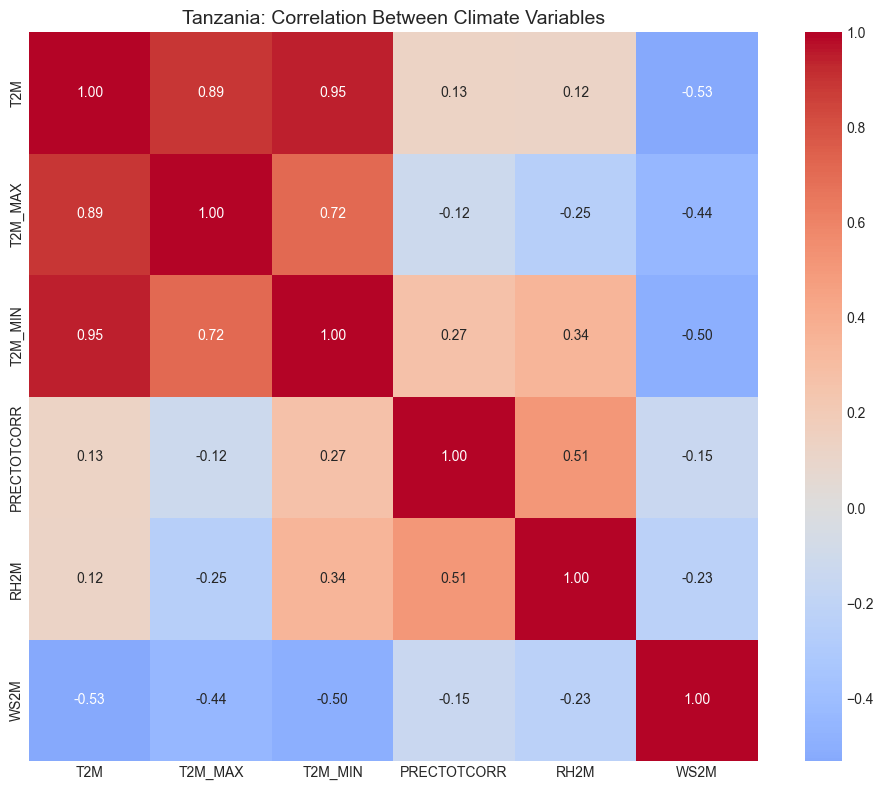

In [ ]:

corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True,
             cmap='coolwarm',
             center=0, 
            fmt='.2f', square=True, ax=ax)

ax.set_title('Tanzania: Correlation Between Climate Variables', fontsize=14)

plt.tight_layout()
plt.show()

# Find strongest correlations
# Get upper triangle of correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corrs = upper_tri.unstack().dropna().abs().sort_values(ascending=False)

## Correlation Analysis

### Three Strongest Correlations

1. **T2M vs T2M_MIN ([0.95])** - Strong positive
   - Nighttime temperatures rise with daytime temperatures

2. ****T2M vs T2M_MAX ([0.89])** - Strong positive
   - Hot days drive higher average temperatures

3. **T2M vs T2M_Min ([0.72])** - Moderate positive
   - Higher humidity associated with rainfall events

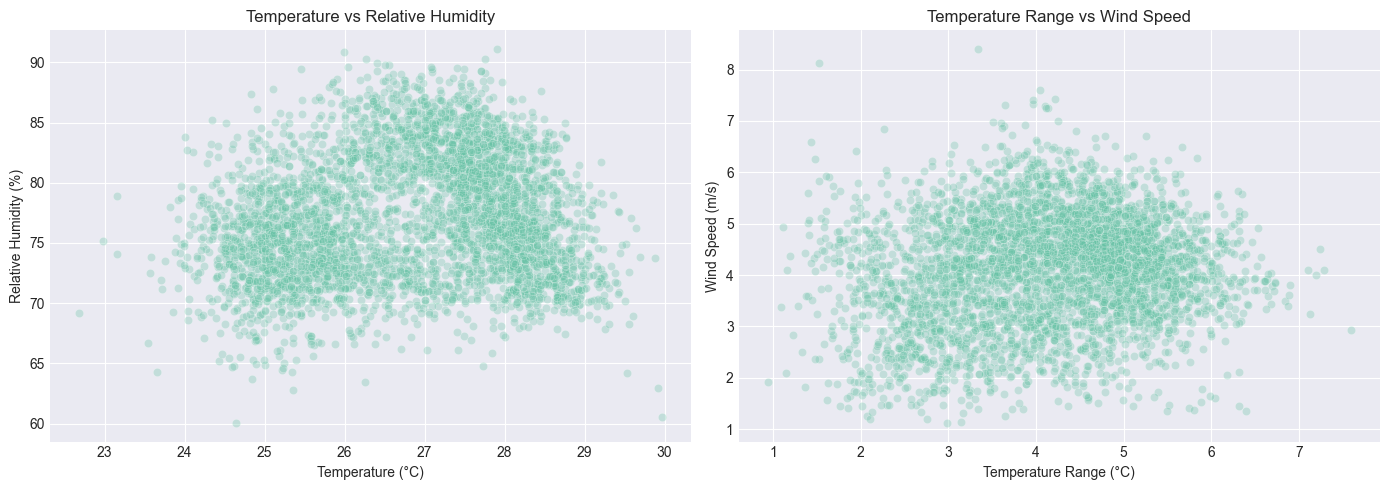

In [ ]:
# Create scatter plots
fig, axes = plt.subplots(1, 2
                         ,figsize=(14, 5))

# Scatter 1: Temperature vs Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')

# Scatter 2: Temperature Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

## Scatter Plot Analysis

### Temperature vs Humidity

- **Pattern:** Negative correlation
- **Interpretation:** Cooler days (23-25°C) show higher humidity (75-90%), while hotter days (28-30°C) show lower humidity (60-70%). Warmer air holds more moisture, causing relative humidity to drop even when actual moisture stays the same.

- **Policy Relevance:** Hot, dry conditions increase evaporation, threatening rain-fed agriculture and raising wildfire risks. Heat-related health impacts are amplified during dry heat events.

### Temperature Range vs Wind Speed

- **Pattern:** Weak positive correlation
- **Interpretation:** Days with larger temperature ranges (5-7°C) show slightly higher wind speeds (4-7 m/s) compared to days with small ranges (1-3°C) and low winds (1-3 m/s). Wind mixes air layers, reducing temperature extremes.

- **Policy Relevance:** High winds combined with large temperature swings accelerate soil moisture loss, affecting crop planning. Tanzania's wind resources also present renewable energy opportunities for COP32 discussions on just energy transition.

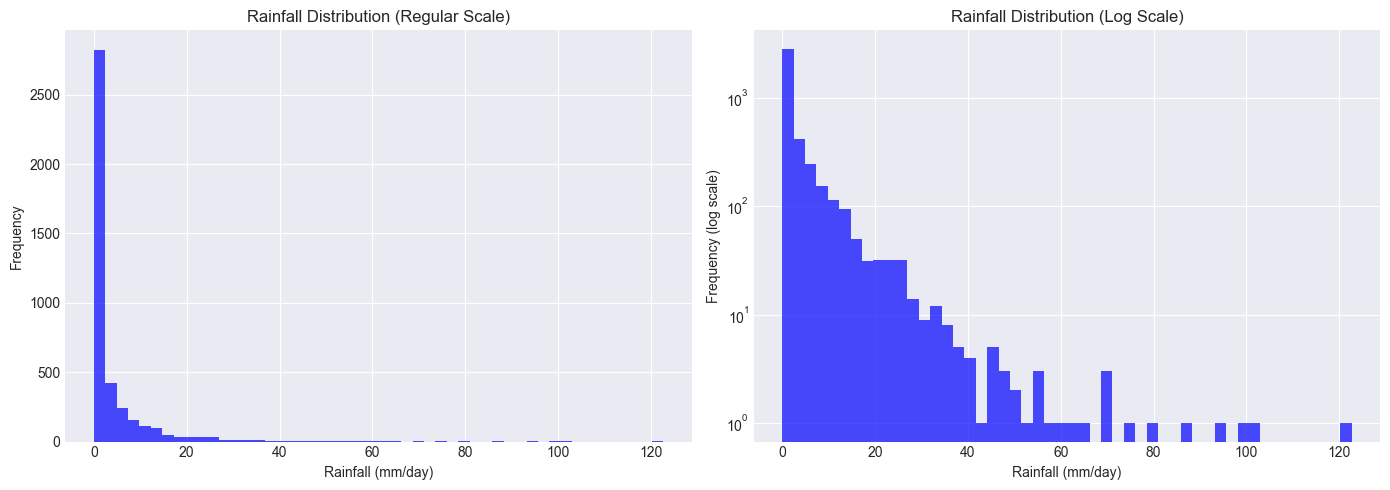

In [ ]:
# Rainfall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular scale
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50
             , color='blue', alpha=0.7)
axes[0].set_title('Rainfall Distribution (Regular Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale (to see pattern better)
axes[1].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7, log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

## Rainfall Distribution Analysis

### Distribution Shape
The rainfall distribution is **highly right-skewed** (exponential distribution), which is typical for precipitation data in semi-arid and tropical climates.

### Log Scale Insight
The log-transformed histogram reveals critical information that the regular scale hides:
- **Heavy rain events (80-120mm), while rare, DO occur**
- These extreme events pose **flash flood risks** even if they happen only a few times per year
- Should include those in agriculture analysis

### Policy Implication for COP32

Tanzania's rainfall distribution shows a **"climate whiplash" pattern**:
- **Drought risk:** Most days are dry → need irrigation, drought-resistant crops
- **Flood risk:** Rare but intense rainfall events → need drainage, early warning systems

**Specific policy asks for COP32:**
1. **Early Warning Systems** for extreme rainfall events
2. **Climate-resilient infrastructure** (flood control, drainage)
3. **Index-based insurance** for farmers (covers both drought AND flood)
4. **Water storage infrastructure** to capture heavy rain for dry periods

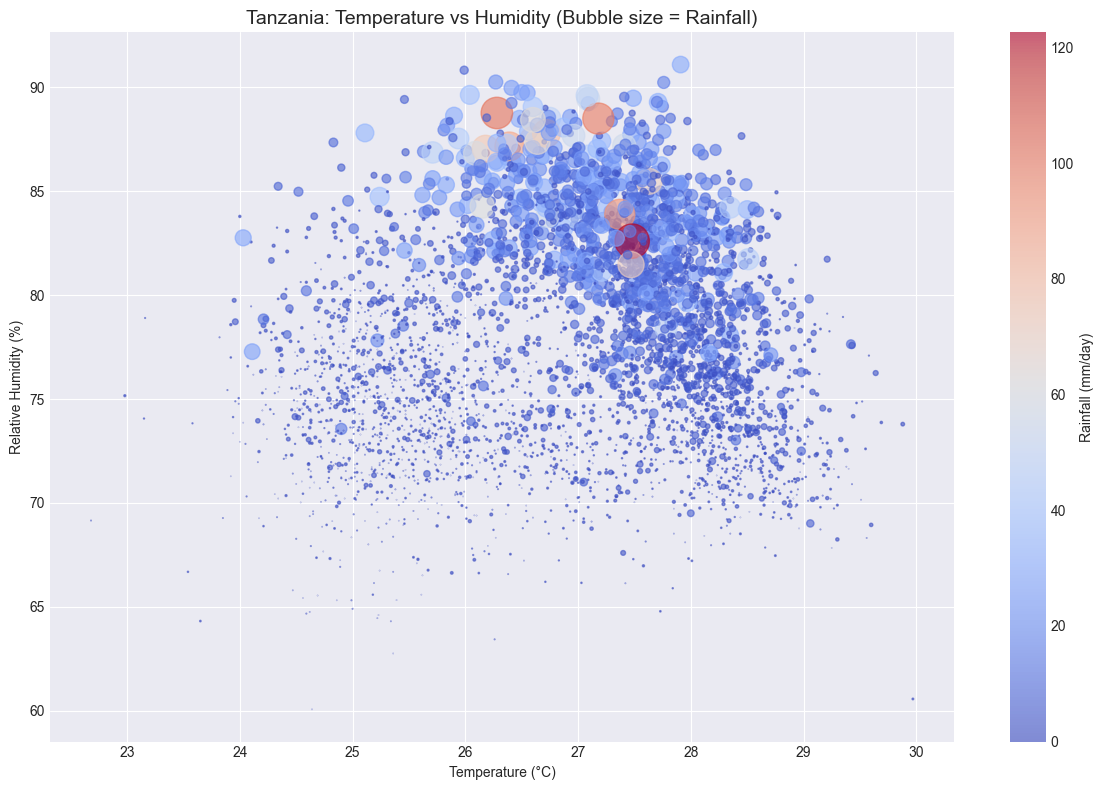

In [17]:
# Bubble chart: Temperature vs Humidity, size = Rainfall
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR'])

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(sample['T2M'], sample['RH2M'], 
                     s=sample['PRECTOTCORR'] * 5,  # Size proportional to rainfall
                     alpha=0.6, c=sample['PRECTOTCORR'], cmap='coolwarm'
                     )

ax.set_title('Tanzania: Temperature vs Humidity (Bubble size = Rainfall)', fontsize=14)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')

plt.colorbar(scatter, label='Rainfall (mm/day)')
plt.tight_layout()
plt.show()

## Multivariate Analysis: Temperature, Humidity, and Rainfall

### Patterns Observed

**Cluster 1: Cool & Humid (23-25°C, 75-90% humidity)**
- Small to medium bubbles (light to moderate rainfall)
- Represents Tanzania's wet season conditions
- Most favorable for rain-fed agriculture

**Cluster 2: Warm & Moderate (25-27°C, 65-80% humidity)**
- Small bubbles (limited rainfall)
- Transition period between wet and dry seasons

**Cluster 3: Hot & Dry (27-30°C, 60-70% humidity)**
- Very small bubbles (little to no rainfall)
- Dry season conditions requiring irrigation
- Heat stress risk for crops and livestock

**Extreme Events:**
- **Large bubbles** (heavy rainfall) occur at moderate temperatures (24-26°C) with high humidity (>80%)
- These represent intense storm events that can cause flooding

### Three-Dimensional Relationship

The bubble chart simultaneously shows:
- **X-axis (Temperature):** Hotter conditions = lower humidity and less rain
- **Y-axis (Humidity):** Higher humidity = cooler temperatures and more rain
- **Bubble size (Rainfall):** Heavy rain events are rare but cluster at moderate temperatures

### Policy Implications for COP32

The interaction of temperature, humidity, and rainfall reveals Tanzania's climate vulnerability:

| Risk | Condition | Policy Ask |
|------|-----------|------------|
| **Drought** | Hot + Dry + Low rain | Irrigation infrastructure, drought-resistant crops |
| **Flood** | Moderate temp + High humidity + Heavy rain | Early warning systems, drainage infrastructure |
| **Heat stress** | High temperature + Low humidity | Cooling centers, heat-health action plans |

### Specific Requests for COP32

1. **Integrated climate risk assessment tools** that capture compound extremes (hot + dry simultaneously)
2. **Early warning systems** for both drought AND flood events
3. **Climate-resilient agriculture packages** combining drought-tolerant varieties with flood management
4. **Water storage infrastructure** to capture heavy rain events for use during dry periods